**Name:** \_\_HAN Zhuo\_\_

**EID:** \_\_zhuohan3\_\_

# CS5489 - Tutorial 2
## Gender Classification from Face Images

In this tutorial you will train a classifier to predict whether a face image is male or female.

First we need to initialize Python.  Run the below cell.

In [1]:
%matplotlib inline
import IPython.core.display         
import matplotlib_inline   # setup output image format
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import matplotlib.pyplot as plt
import matplotlib
from numpy import *
from sklearn import *
import os
import zipfile
import fnmatch
random.seed(100)

## Loading Data and Pre-processing
We first need to load the images.  Download `photos-bw.zip` and put it in the same directory as this ipynb file.  **Do not unzip the file.** Then run the following cell to load the images.

In [2]:
imgdata = []
genders = []

# load the zip file
filename = 'photos-bw.zip'
zfile = zipfile.ZipFile(filename, 'r')

for name in zfile.namelist():
    # check file name matches
    if fnmatch.fnmatch(name, "photos-bw/*.png"):
        print("loading", name)
        # open file in memory, and parse as an image
        myfile = zfile.open(name)
        img = matplotlib.image.imread(myfile)
        myfile.close()
        
        # append to data
        imgdata.append(img)
        genders.append( int(name[len("photos-bw/")] == 'm') )  # 0 is female, 1 is male
        
zfile.close()
imgsize = img.shape
print("DONE: loaded {} images".format(len(imgdata)))

loading photos-bw/f-039-01.png
loading photos-bw/f-040-01.png
loading photos-bw/f-041-01.png
loading photos-bw/f-042-01.png
loading photos-bw/f-043-01.png
loading photos-bw/f1-001-0.png
loading photos-bw/f1-002-0.png
loading photos-bw/f1-003-0.png
loading photos-bw/f1-004-0.png
loading photos-bw/f1-005-0.png
loading photos-bw/f1-006-0.png
loading photos-bw/f1-007-0.png
loading photos-bw/f1-008-0.png
loading photos-bw/f1-009-0.png
loading photos-bw/f1-010-0.png
loading photos-bw/f1-011-0.png
loading photos-bw/f1-012-0.png
loading photos-bw/f1-013-0.png
loading photos-bw/f1-014-0.png
loading photos-bw/f1-015-0.png
loading photos-bw/m-063-01.png
loading photos-bw/m-064-01.png
loading photos-bw/m-065-01.png
loading photos-bw/m-067-01.png
loading photos-bw/m-069-01.png
loading photos-bw/m-070-01.png
loading photos-bw/m-073-01.png
loading photos-bw/m-074-01.png
loading photos-bw/m-075-01.png
loading photos-bw/m-077-01.png
loading photos-bw/m-083-01.png
loading photos-bw/m-085-01.png
loading 

Each image is a 45x40 array of pixel values.  Run the below code to show an example:

(45, 40)


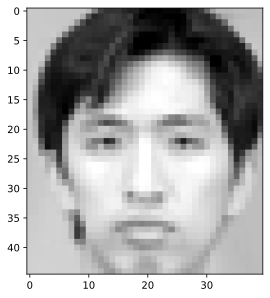

In [3]:
print(img.shape)
plt.imshow(img, cmap='gray', interpolation='nearest')
plt.show()

Run the below code to show all the images!

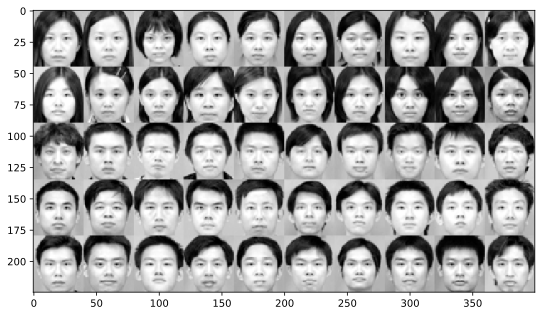

In [4]:
# function to make an image montage
def image_montage(X, imsize=None, maxw=10):
    """X can be a list of images, or a matrix of vectorized images.
      Specify imsize when X is a matrix."""
    tmp = []
    numimgs = len(X)
    
    # create a list of images (reshape if necessary)
    for i in range(0,numimgs):
        if imsize != None:
            tmp.append(X[i].reshape(imsize))
        else:
            tmp.append(X[i])
    
    # add blanks
    if (numimgs > maxw) and (mod(numimgs, maxw) > 0):
        leftover = maxw - mod(numimgs, maxw)
        meanimg = 0.5*(X[0].max()+X[0].min())
        for i in range(0,leftover):
            tmp.append(ones(tmp[0].shape)*meanimg)
    
    # make the montage
    tmp2 = []
    for i in range(0,len(tmp),maxw):
        tmp2.append( hstack(tmp[i:i+maxw]) )
    montimg = vstack(tmp2) 
    return montimg

plt.figure(figsize=(9,9))
plt.imshow(image_montage(imgdata), cmap='gray', interpolation='nearest')
plt.show()

Each image is a 2d array, but the classifier algorithms work on 1d vectors. Run the following code to convert all the images into 1d vectors by flattening.  The result should be a matrix where each row is a flattened image.

In [5]:
X = empty((50, prod(imgdata[0].shape))) # create empty array
for i,img in enumerate(imgdata):
    X[i,:] = ravel(img)           # for each image, turn it into a vector
Y = asarray(genders)  # convert list to numpy array
print(X.shape)
print(Y.shape)

(50, 1800)
(50,)


Next we will shift the pixel values so that gray is 0.0, black is -0.5 and white is 0.5.

In [ ]:
print("Before: min={}, max={}".format(X.min(), X.max()))
X -= 0.5
print("After:  min={}, max={}".format(X.min(), X.max()))

Finally, split the dataset into a training set and testing set. We select 80% for training and 20% for testing.

In [6]:
# randomly split data into 80% train and 20% test set
trainX, testX, trainY, testY = \
  model_selection.train_test_split(X, Y, 
  train_size=0.80, test_size=0.20, random_state=4487)

print(trainX.shape)
print(testX.shape)

(40, 1800)
(10, 1800)


In [7]:
# compute the average image for later
avgX = mean(X,axis=0)

# Logistic Regression
Train a logistic regression classifier.  Use cross-validation to select the best C parameter.

**NOTE:** If you are running on DeepDive server, the number of effective jobs is 4, i.e. `n_jobs=-1` will use 4 CPUs.

In [10]:
### INSERT YOUR CODE HERE
logreg = linear_model.LogisticRegression(C=100)
logreg.fit(trainX, trainY)

print("w =", logreg.coef_)
print("b =", logreg.intercept_)

w = [[-0.04802925 -0.04424267 -0.04253797 ...  0.03803668  0.01004547
   0.03376012]]
b = [-0.06501695]


In [11]:
predY = logreg.predict(testX)
accuracy = metrics.accuracy_score(testY, predY)
print("Accuracy on test set: {:.2f}%".format(accuracy*100))

Accuracy on test set: 80.00%


Use the learned model to predict the genders for the training and testing data. What is the accuracy on the training set? What is the accuracy on the testing set?

In [18]:
### INSERT YOUR CODE HERE
train_predY = logreg.predict(trainX)
train_accuracy = metrics.accuracy_score(trainY, train_predY)
print("Accuracy on train set: {:.2f}%".format(train_accuracy*100))

predYtest = logreg.predict(testX)
test_accuracy = metrics.accuracy_score(testY, predYtest)
print("Accuracy on test set: {:.2f}%".format(test_accuracy*100))

Accuracy on train set: 100.00%
Accuracy on test set: 80.00%


The accuracy on the training set is 100%, and the accuracy on the testing set is 80%.

## Analyzing the classifier
Run the below code to show the hyperplane parameter $\mathbf{w}$ as an image.  

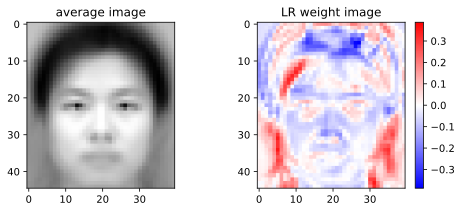

In [16]:
# logreg is the learned logistic regression model
import numpy as np
wimg = logreg.coef_.reshape(imgsize)      # get the w and reshape into an image
mycmap = matplotlib.colors.LinearSegmentedColormap.from_list('mycmap', ["#0000FF", "#FFFFFF", "#FF0000"])
# mm = max(wimg.max(), -wimg.min())
mm = np.abs(wimg).max()
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.title('average image')
plt.imshow(avgX.reshape(imgsize), cmap='gray')
plt.subplot(1,2,2)
plt.imshow(wimg, interpolation='nearest', cmap=mycmap, vmin=-mm, vmax=mm)
plt.colorbar()
plt.title("LR weight image")
plt.show()

Recall that the classifier prediction is based on the sign of the function $f(\mathbf{x}) = \mathbf{w}^T\mathbf{x}+b = \sum_{i=1}^P w_ix_i + b$.  Here each $x_i$ is a pixel in the face image, and $w_i$ is the corresponding weight.  Hence, the function is multiplying face image by the weight image, and then summing over all pixels.

In order for $f(\mathbf{x})$ to be positive, then the positive values of the weight image (red regions) should match the positive values in the face image (white pixels), and the negative values of the weight image (blue regions) should be matched with negative values in the face image (black pixels).

Hence, we can have the following interpretation:
<table>
<tr><th>Class</th><th>red regions (positive weights)</th><th>blue regions (negative weights)</th><th>white regions (weights near 0)</th></tr>
<tr><td>+1 class (male)</td><td>white pixels in face image</td><td>black pixels in face image</td><td>region not important</td></tr>
<tr><td>-1 class (female)</td><td>black pixels in face image</td><td>white pixels in face image</td><td>region not important</td></tr>
</table>
  
_Looking at the weight image, what parts of the face image is the classifier looking at to determine the gender?  Does it make sense?_

- **INSERT YOUR ANSWER HERE**
1. The classifier mainly looks at the eyes, hairline, as well as the lower half of the background to determine if the image is classified as a male (when those parts are white pixels); meanwhile, it looks at the nose, cheek, and chin areas to determine if the image is classified as a female (when those parts are black pixels).
2. This makes sense to some extend, as these areas usually represents the corresponding facial features of the two sexes, for example a less emphasized chin might belong to a female face, and receding hairline might belong to a male face. But there are other aspects that does not make sense, for example, the classifier determines a picture as male if the lower half of the background has high positive values. This could be interpreted as indirect bias, possibly capturing the presence of shorter hair (often associated with males). However, this is not truly a facial feature, and it introduces the risk of misclassifying females with shorter hair as males.

Now let's look at the misclassified faces in the test set.  Run the below code to show the misclassifed and correctly classified faces.

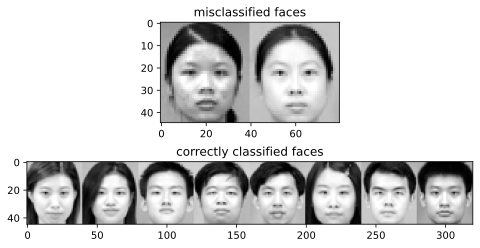

In [20]:
# predYtest are the class predictions on the test set.

# find misclassified test images
inds = where(predYtest != testY) # get indices of misclassified test images
# make a montage
badimgs = image_montage(testX[inds], imsize=imgsize)

# find correctly classified test images
inds = where(predYtest == testY)
goodimgs = image_montage(testX[inds], imsize=imgsize)
    
plt.figure(figsize=(8,4))
plt.subplot(2,1,1)
plt.imshow(badimgs, cmap='gray', interpolation='nearest')
plt.title('misclassified faces')
plt.subplot(2,1,2)
plt.imshow(goodimgs, cmap='gray', interpolation='nearest')
plt.title('correctly classified faces')
plt.show()

_Why did the classifier make incorrect predictions on the misclassified faces?_
- **INSERT YOUR ANSWER HERE**
1. The classifier made incorrect predictions on the misclassified faces because the decision boundary it learned is mainly based on local pixel density rather than recognizing real features that have realistic meanings. In this case, when a female has less visible hair could lead to misclassification (e.g., the second misclassified case). Moreover, the brightness of the image as a whole greatly impacts the determination (again, because of the classifier mainly learns how to judge based on pixel density). And when an image is in general darker (e.g., the first misclassified case), it could confuse the classifier.


# Support Vector Machine
Now train a support vector machine (SVM) on the same training and testing data.  Use cross-validation to select the best $C$ parameter.

In [23]:
### INSERT YOUR CODE HERE
paramgrid = {'C': np.logspace(-3, 3, 1000)}
svmcv = model_selection.GridSearchCV(
    svm.SVC(kernel='linear'),
    paramgrid,
    cv = 5,
    n_jobs = -1,
    verbose=True
)
svmcv.fit(trainX, trainY)
print("Best C:", svmcv.best_params_)
best_svm = svmcv.best_estimator_

Fitting 5 folds for each of 1000 candidates, totalling 5000 fits
Best C: {'C': np.float64(0.004213321743847289)}


Calculate the training and test accuracy for the SVM classifier.

In [25]:
### INSERT YOUR CODE HERE
pred_train = best_svm.predict(trainX)
train_accuracy = metrics.accuracy_score(trainY, pred_train)

print("Accuracy on train set: {:.2f}%".format(train_accuracy*100))

pred_test = best_svm.predict(testX)
test_accuracy = metrics.accuracy_score(testY, pred_test)

print("Accuracy on test set: {:.2f}%".format(test_accuracy*100))

Accuracy on train set: 90.00%
Accuracy on test set: 80.00%


Similar to before, plot an image of the hyperplane parameters $w$, and view the misclassified and correctly classified test images.

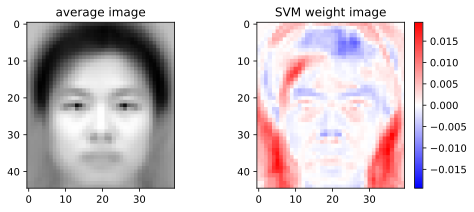

In [26]:
### INSERT YOUR CODE HERE
wimg_svm = best_svm.coef_.reshape(imgsize)
mycmap_svm = matplotlib.colors.LinearSegmentedColormap.from_list('mycmap', ["#0000FF", "#FFFFFF", "#FF0000"])
mm_svm = np.abs(wimg_svm).max()
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.title('average image')
plt.imshow(avgX.reshape(imgsize), cmap='gray')
plt.subplot(1,2,2)
plt.imshow(wimg_svm, interpolation='nearest', cmap=mycmap_svm, vmin=-mm_svm, vmax=mm_svm)
plt.colorbar()
plt.title("SVM weight image")
plt.show()

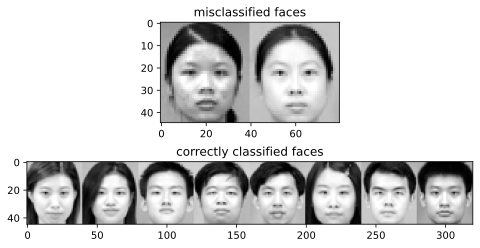

In [29]:
predTest_svm = best_svm.predict(testX)
bad_idx = where(predTest_svm != testY)
good_idx = where(predTest_svm == testY)

badimgs_svm = image_montage(testX[bad_idx], imsize=imgsize)
goodimgs_svm = image_montage(testX[good_idx], imsize=imgsize)

plt.figure(figsize=(8,4))
plt.subplot(2,1,1)
plt.imshow(badimgs_svm, cmap='gray', interpolation='nearest')
plt.title('misclassified faces')
plt.subplot(2,1,2)
plt.imshow(goodimgs_svm, cmap='gray', interpolation='nearest')
plt.title('correctly classified faces')
plt.show()

_Are there any differences between the $w$ for logistic regressiona and the $w$ for SVM?  Is there any interpretation for the differences?_

- **INSERT YOUR ANSWER HERE**
1. From the two weight images, we can see that both LR and SVM identify similar regions of the face as import for gender classification, such as the hairline, eyes, nose and chin. However, there are several differences between the two models.
    a. The LR weight map has a much larger range (i.e., from -0.3 to +0.3), while the SVM weights are much smaller (i.e., from -0.015 to +0.015). This is because LR directly models the probability of each class and often produces stronger coefficients, while SVM maximizes the margin between classes, leading to more regularized and balanced weights.
    b. LR tends to produce sharper contrasts and highlighs specific local features more strongly (e.g., the chin area, the nose region, etc.). In contrast, the SVM spreads weights across broader regions of the image (e.g., the entire hairline and face contour), resulting in smoother weight patterns.
2. These differences make sense given the underlying principles of the two classifiers. LR is a probabilistic model that optimizes likelihood, which can lead to large coefficients for highly discriminative features. SVM on the other hand is a geometric model that maximizes the margin between classes, so it spreads out the influence of features more evenly.

# Classifying cropped faces
It seems that the hair around the face and forehead are discriminative enough to perform gender classifixation. Now try to perform the same task but only focusing on the face image, and not the hair.

First, we define a mask over the face.

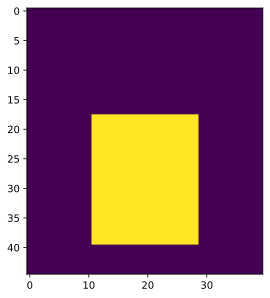

In [30]:
imgmask = full((img.shape), False)
#imgmask[17:41,8:32] = True
#masksize = (24,24)
imgmask[18:40,11:29] = True
masksize = (22,18)
plt.imshow(imgmask)

Next we crop out the face image to create the new inputs.  The vectors are now 576-dim, and corresponding images are 24x24.

In [31]:
Xm = X[:,imgmask.ravel()]
Xm.shape

(50, 396)

Here are the cropped images.

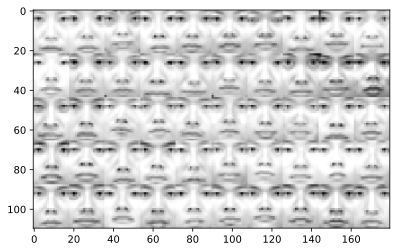

In [32]:
plt.imshow(image_montage(Xm, imsize=masksize), cmap='gray', interpolation='nearest')

Generate the same training/test split as before

In [33]:
# randomly split data into 80% train and 20% test set
trainXm, testXm, trainY, testY = \
  model_selection.train_test_split(Xm, Y, 
  train_size=0.80, test_size=0.20, random_state=4487)

print(trainXm.shape)
print(testXm.shape)

(40, 396)
(10, 396)


In [34]:
avgXm = avgX[imgmask.ravel()]

Now train logistic regression and SVM classifiers on the new cropped images.

In [35]:
### INSERT YOUR CODE HERE
logreg_chopped = linear_model.LogisticRegression(C=100)
logreg_chopped.fit(trainXm, trainY)

print("w =", logreg_chopped.coef_)
print("b =", logreg_chopped.intercept_)

w = [[ 1.40762232e+00 -3.03121017e-02 -1.07774023e+00 -1.28768442e+00
  -1.25779724e+00 -4.58297384e-01 -5.78038761e-01 -2.43781957e-02
   4.29865343e-01  2.21734031e-01  3.83661537e-01 -2.17355258e-01
   2.82348531e-01  2.58582613e-01  2.52110607e-01  5.86676592e-01
  -4.98227531e-02  9.64498048e-01 -1.04752047e+00 -2.39938112e+00
  -1.37389704e+00 -9.35248594e-01 -8.99926370e-01 -9.23218962e-01
  -1.73151055e+00 -1.08793052e+00  4.42559235e-02  1.79266136e-01
  -4.43334360e-01 -1.41996050e+00 -1.26137023e+00 -1.35238576e+00
  -1.53744225e+00 -2.19130645e+00 -2.58245442e+00 -1.95950808e+00
  -7.07170923e-01 -6.69872644e-01 -2.68151570e-01 -4.86615081e-02
  -6.47694276e-02 -5.54956877e-01 -1.14886666e+00 -9.85153251e-01
  -3.87071379e-01 -2.56258553e-01 -8.53628715e-01 -1.26985786e+00
  -1.08484624e+00 -1.98857339e-01  3.22286441e-01  1.12826319e-01
  -1.11621009e-02 -6.93044012e-01  1.93418228e+00  2.10818764e+00
   2.01702275e+00  1.18282510e+00  5.95547583e-01  2.25026423e-01
  -2.0

In [36]:
### INSERT YOUR CODE HERE
predY_chopped = logreg_chopped.predict(testXm)
accuracy_chopped = metrics.accuracy_score(testY, predY_chopped)
print("Accuracy on test set: {:.2f}%".format(accuracy_chopped*100))

Accuracy on test set: 80.00%


Compute the train/test accuracies of the two classifiers.

In [37]:
### INSERT YOUR CODE HERE
train_predY_chopped = logreg_chopped.predict(trainXm)
train_accuracy_chopped = metrics.accuracy_score(trainY, train_predY_chopped)
print("Accuracy on train set: {:.2f}%".format(train_accuracy_chopped*100))

test_predY_chopped = logreg_chopped.predict(testXm)
test_accuracy_chopped = metrics.accuracy_score(testY, test_predY_chopped)
print("Accuracy on test set: {:.2f}%".format(test_accuracy_chopped*100))

Accuracy on train set: 100.00%
Accuracy on test set: 80.00%


In [43]:
param_grid_chopped = {'C': np.logspace(-3, 3, 1000)}
svmcv_chopped = model_selection.GridSearchCV(
    svm.SVC(kernel='linear'),
    param_grid_chopped,
    cv = 5,
    n_jobs = -1,
    verbose=True
)
svmcv_chopped.fit(trainXm, trainY)
print("Best C:", svmcv_chopped.best_params_)
best_svm_chopped = svmcv_chopped.best_estimator_

Fitting 5 folds for each of 1000 candidates, totalling 5000 fits
Best C: {'C': np.float64(0.36187498124112805)}


In [44]:
train_predY_svm_chopped = best_svm_chopped.predict(trainXm)
train_accuracy_svm_chopped = metrics.accuracy_score(trainY, train_predY_svm_chopped)
print("Accuracy on train set: {:.2f}%".format(train_accuracy_svm_chopped*100))

test_predY_svm_chopped = best_svm_chopped.predict(testXm)
test_accuracy_svm_chopped = metrics.accuracy_score(testY, test_predY_svm_chopped)
print("Accuracy on test set: {:.2f}%".format(test_accuracy_svm_chopped*100))

Accuracy on train set: 95.00%
Accuracy on test set: 70.00%


Compare the classification performance? Which performs better and why?

- **INSERT YOUR ANSWER HERE**

Visualize the weights as an image and interpret what discriminative information each classifier is using.

In [ ]:
### INSERT YOUR CODE HERE

In [ ]:
### INSERT YOUR CODE HERE

- **INSERT YOUR ANSWER HERE**

## Custom kernel SVM

Now we will try to use a custom kernel with the SVM (for classifying cropped faces).  We will consider the following RBF-like kernel based on L1 distance (i.e., cityblock or Manhattan distance),

$$ k(\mathbf{x},\mathbf{y}) = \exp \left(-\alpha \sum_{i=1}^d |x_i-y_i|\right)$$

where $x_i,y_i$ are the elements of the vectors $\mathbf{x},\mathbf{y}$, and $\alpha$ is the hyperparameter.  The difference with the RBF kernel is that the new kernel uses the absolute difference rather than the squared difference. Thus, the new kernel does not "drop off" as fast as the RBF kernel using squared distance.

- Implement the new kernel as a custom kernel function, `svm.SVC` can accept a self-defined callable kernel function as the kernel argument. The `scipy.spatial.distance.cdist` function will be helpful.
- Train the SVM with the new kernel.  To select the hyperparameter $\alpha$, you need to run cross-validation "manually" by: 1) trying different values of $\alpha$, and running cross-validation to select $C$; 2) selecting the  $\alpha$ with the highest cross-validation score `best_score_` in `GridSearchCV`.


In [ ]:
### INSERT YOUR CODE HERE

In [ ]:
### INSERT YOUR CODE HERE


Does using the new kernel improve the results?
- **INSERT YOUR ANSWER HERE**